# Deliverable 1: Data Collection, Cleaning, and Exploration

**Course Project:** Advanced Data Mining for Data-Driven Insights and Predictive Modeling  
**Dataset:** Healthcare records (55,500 rows, 15 columns)

This notebook covers Deliverable 1 requirements:

1. Dataset selection and justification
2. Data loading and structural inspection
3. Data cleaning (missing values, duplicates, inconsistencies, noisy data)
4. Exploratory data analysis (EDA) with visualizations
5. Key insights and how they inform future modeling


## 1) Dataset Description and Justification

This healthcare dataset is appropriate for the project because it:

- Contains more than the required 500 records (55,500 records).
- Contains 15 attributes (exceeds the required 8-10 attributes).
- Includes mixed data types (numeric, categorical, dates), which supports multiple data mining tasks.
- Is rich enough for future project phases such as regression, classification, clustering, and association analysis.

Potential practical questions supported by this dataset:

- What factors are associated with higher billing amounts?
- How do admission types and medical conditions relate to length of stay?
- Can we predict billing cost or test outcomes from patient/hospital features?


In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display settings for easier inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# Plot style
sns.set_theme(style='whitegrid', context='notebook')

In [5]:
# Load dataset
file_path = 'healthcare_dataset.csv'
df = pd.read_csv(file_path)

# Keep an untouched copy for comparison when needed
raw_df = df.copy()

print('Shape:', df.shape)
df.head()

Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
# Inspect structure and data types
df.info()

# Summary stats for numeric columns
df.describe(include='all').T.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,49992,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.0,NaN,NaN,NaN,51.539459,19.602454,13.0,35.0,52.0,68.0,89.0
Gender,55500,2,Male,27774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,A-,6969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,6,Arthritis,9308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,39876,LLC Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.0,NaN,NaN,NaN,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736


## 2) Data Cleaning

Cleaning strategy used:

- Check and handle missing values
- Detect and remove duplicates
- Normalize text formatting inconsistencies (e.g., mixed upper/lower case in names)
- Parse date columns and derive length of stay
- Identify noisy values in billing and treat negative costs as anomalies


In [ ]:
# Standardize column names for easier downstream use
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# 1) Missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
print('Missing values per column:\n', missing_counts)

# 2) Duplicate rows
dup_count = df.duplicated().sum()
print(f'\nDuplicate rows before cleaning: {dup_count}')
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after duplicate removal:', df.shape)

# 3) Fix common text inconsistencies
text_cols = ['name', 'gender', 'blood_type', 'medical_condition', 'doctor',
             'hospital', 'insurance_provider', 'admission_type', 'medication', 'test_results']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Normalize case where appropriate
df['name'] = df['name'].str.title()
df['doctor'] = df['doctor'].str.title()
df['hospital'] = df['hospital'].str.title()
df['medical_condition'] = df['medical_condition'].str.title()
df['admission_type'] = df['admission_type'].str.title()
df['insurance_provider'] = df['insurance_provider'].str.title()
df['medication'] = df['medication'].str.title()
df['test_results'] = df['test_results'].str.title()
df['gender'] = df['gender'].str.title()

# 4) Parse date columns and derive length of stay
df['date_of_admission'] = pd.to_datetime(
    df['date_of_admission'], errors='coerce')
df['discharge_date'] = pd.to_datetime(df['discharge_date'], errors='coerce')
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

# 5) Noisy data handling for billing amount
# Negative billing values are treated as anomalies and replaced with the median of non-negative values.
neg_billing = (df['billing_amount'] < 0).sum()
print(f'\nNegative billing entries before treatment: {neg_billing}')
if neg_billing > 0:
    median_non_negative = df.loc[df['billing_amount']
                                 >= 0, 'billing_amount'].median()
    df.loc[df['billing_amount'] < 0, 'billing_amount'] = median_non_negative

# Final validation check after cleaning
print('\nMissing values after cleaning:\n', df.isna().sum())
print('Duplicate rows after cleaning:', df.duplicated().sum())
print('Any negative billing left:', (df['billing_amount'] < 0).any())

Missing values per column:
 name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
dtype: int64

Duplicate rows before cleaning: 534
Shape after duplicate removal: (54966, 15)

Negative billing entries before treatment: 106

Missing values after cleaning:
 name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
length_of_stay        0
dtype: int64
Duplicate rows after cleaning: 0
Any nega

In [ ]:
# Quick post-clean profile
print('Cleaned shape:', df.shape)
print('\nUnique counts for key categorical features:')
print(df[['gender', 'blood_type', 'medical_condition',
      'admission_type', 'insurance_provider', 'test_results']].nunique())

df.head()

Cleaned shape: (54966, 16)

Unique counts for key categorical features:
gender                2
blood_type            8
medical_condition     6
admission_type        3
insurance_provider    5
test_results          3
dtype: int64


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,length_of_stay
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


## 3) Exploratory Data Analysis (EDA)


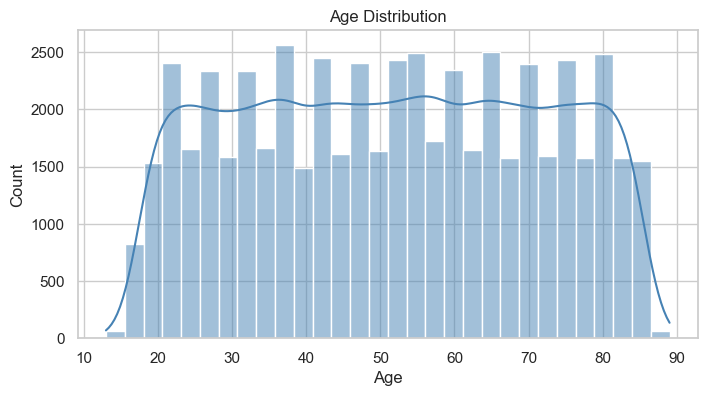

In [10]:
# Distribution of age
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

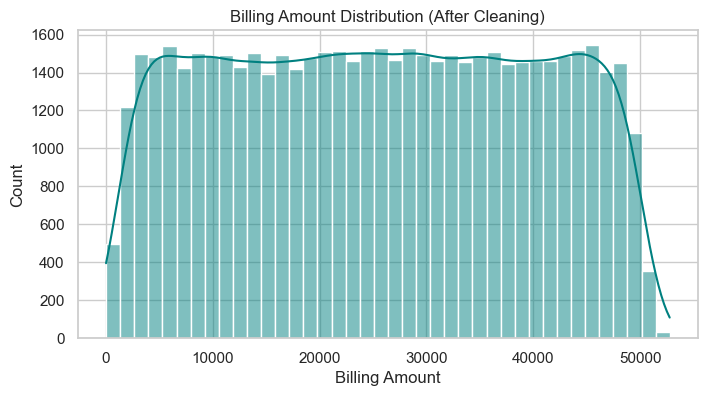

In [11]:
# Billing amount distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['billing_amount'], bins=40, kde=True, color='teal')
plt.title('Billing Amount Distribution (After Cleaning)')
plt.xlabel('Billing Amount')
plt.ylabel('Count')
plt.show()

/var/folders/v5/2dnyj4hn4q13nbgkpmzk9cvr0000gn/T/ipykernel_61044/3154717316.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='medical_condition', order=order, palette='Set2')


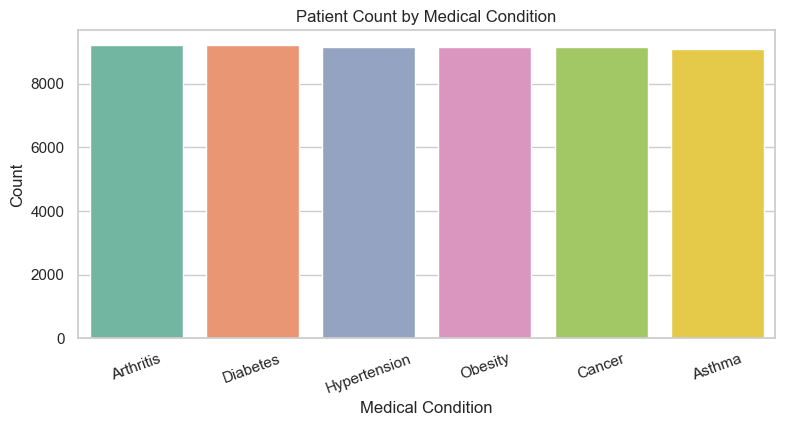

In [12]:
# Medical condition counts
plt.figure(figsize=(9, 4))
order = df['medical_condition'].value_counts().index
sns.countplot(data=df, x='medical_condition', order=order, palette='Set2')
plt.title('Patient Count by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

/var/folders/v5/2dnyj4hn4q13nbgkpmzk9cvr0000gn/T/ipykernel_61044/340368677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='admission_type', y='billing_amount', palette='Set3')


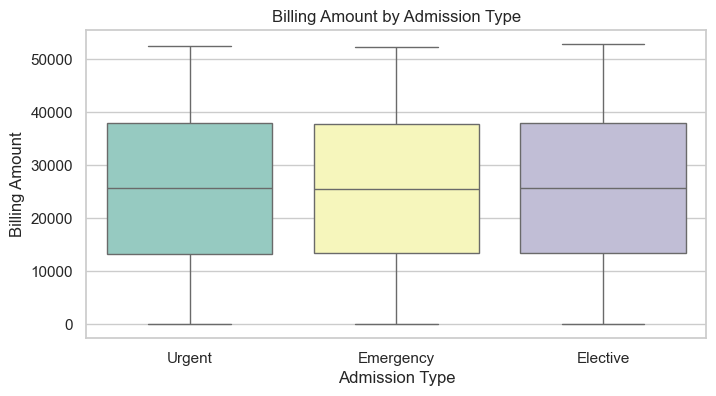

In [13]:
# Compare billing amount across admission types
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='admission_type', y='billing_amount', palette='Set3')
plt.title('Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Billing Amount')
plt.show()

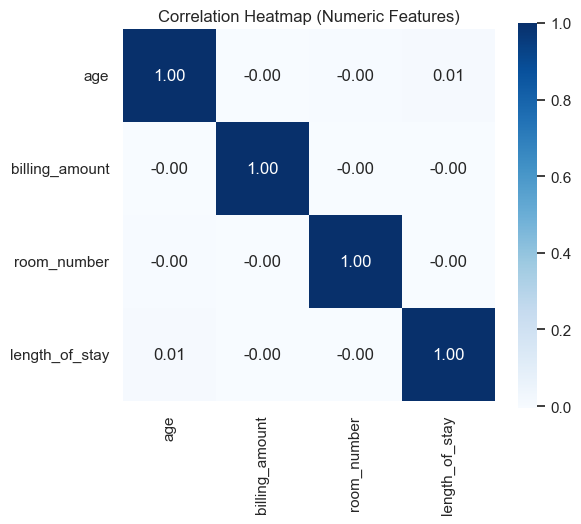

In [14]:
# Numeric feature relationships
numeric_cols = ['age', 'billing_amount', 'room_number', 'length_of_stay']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

/var/folders/v5/2dnyj4hn4q13nbgkpmzk9cvr0000gn/T/ipykernel_61044/3884935846.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=los_by_condition, x='medical_condition',


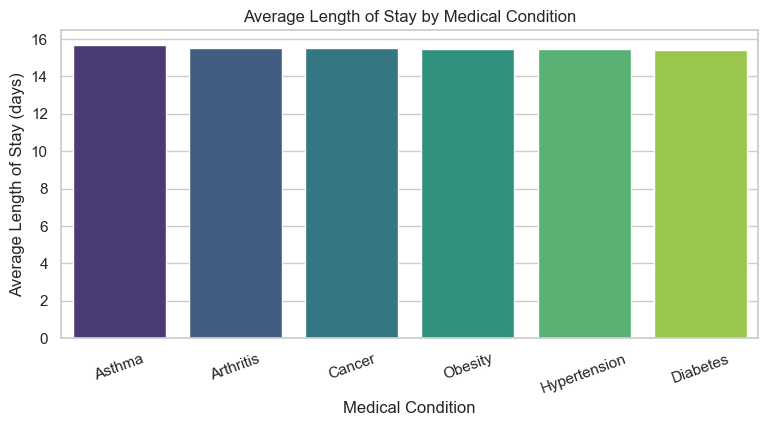

,medical_condition,length_of_stay
1,Asthma,15.677295
0,Arthritis,15.504231
2,Cancer,15.501204
5,Obesity,15.447627
4,Hypertension,15.436236
3,Diabetes,15.430664


In [15]:
# Additional EDA: average length of stay by medical condition
los_by_condition = df.groupby('medical_condition', as_index=False)[
    'length_of_stay'].mean().sort_values('length_of_stay', ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(data=los_by_condition, x='medical_condition',
            y='length_of_stay', palette='viridis')
plt.title('Average Length of Stay by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Length of Stay (days)')
plt.xticks(rotation=20)
plt.show()

los_by_condition

## 4) Insights From EDA

Key findings from cleaning and EDA:

- The dataset is large and balanced across key classes (e.g., admission type and gender), which is useful for stable model training.
- Duplicate rows existed and were removed, improving data reliability.
- Mixed-case text inconsistencies (especially names and providers) were normalized to reduce category noise.
- A small number of negative billing values were detected and treated as anomalies.
- Medical conditions are distributed relatively evenly, which can support fairer downstream comparisons.
- Length of stay variability can be used as an informative engineered feature for future regression/classification tasks.


## 5) How This Guides Future Modeling Steps

These Deliverable 1 results directly support later phases:

- **Deliverable 2 (Regression):** use cleaned numeric/categorical features to predict `billing_amount` or `length_of_stay`.
- **Deliverable 3 (Classification/Clustering/Association):** use standardized categories (`medical_condition`, `admission_type`, `test_results`, `medication`) for class prediction and pattern mining.
- Cleaned dates and engineered length-of-stay improve explanatory power and model interpretability.

Optional export of cleaned data is provided below.


In [16]:
# Optional: save cleaned dataset for use in subsequent deliverables
clean_path = 'healthcare_dataset_cleaned.csv'
df.to_csv(clean_path, index=False)
print(f'Cleaned dataset saved to: {clean_path}')

Cleaned dataset saved to: healthcare_dataset_cleaned.csv
